In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap

# 2. Load dataset
df = pd.read_csv("/content/Iris.csv")

# Drop ID column if it exists
df.drop('Id', axis=1, inplace=True)

# Encode categorical target
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# 3. Normalize features
X = df.drop('Species', axis=1)
y = df['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [3]:
#2. Use KNeighborsClassifier from sklearn & 3. Try Different K
# Try K values from 1 to 10
k_range = range(1, 11)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"K = {k}, Accuracy = {acc:.2f}")

K = 1, Accuracy = 0.97
K = 2, Accuracy = 1.00
K = 3, Accuracy = 1.00
K = 4, Accuracy = 1.00
K = 5, Accuracy = 1.00
K = 6, Accuracy = 1.00
K = 7, Accuracy = 1.00
K = 8, Accuracy = 1.00
K = 9, Accuracy = 1.00
K = 10, Accuracy = 1.00


Final Accuracy: 1.0


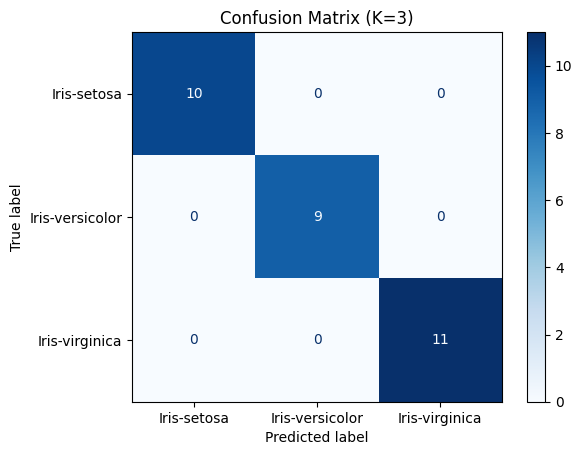

In [4]:
#4.Evaluate with accuracy and confusion matirx
# Choose best K (e.g., K = 3)
best_k = 3
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Accuracy
print("Final Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()

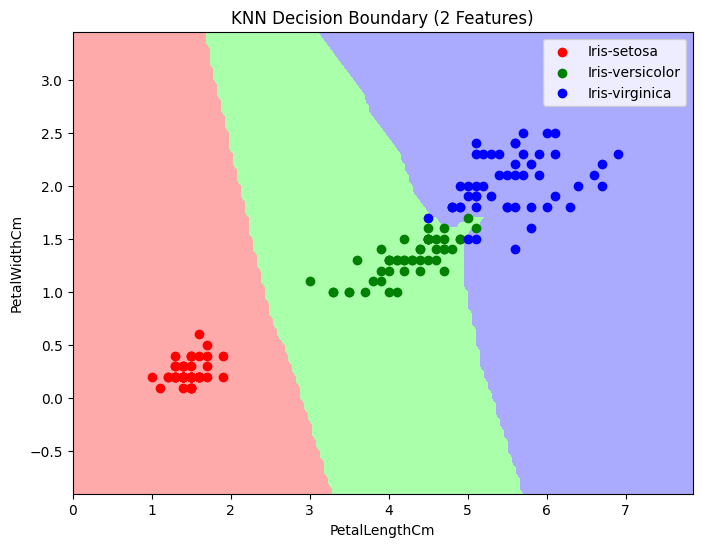

In [5]:
#5.Visualise decision bounderies
# Use only two features for plotting
X_2d = df[['PetalLengthCm', 'PetalWidthCm']].values
y_2d = df['Species'].values

X_train2d, X_test2d, y_train2d, y_test2d = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

# Train KNN on 2D features
knn_2d = KNeighborsClassifier(n_neighbors=3)
knn_2d.fit(X_train2d, y_train2d)

# Plot decision boundary
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.contourf(xx, yy, Z, cmap=cmap_light)
for i, color in zip(np.unique(y_2d), cmap_bold):
    plt.scatter(X_2d[y_2d == i, 0], X_2d[y_2d == i, 1], label=le.classes_[i], color=color)

plt.xlabel('PetalLengthCm')
plt.ylabel('PetalWidthCm')
plt.title("KNN Decision Boundary (2 Features)")
plt.legend()
plt.show()
